# Student Performance Prediction

## Project Overview

This notebook develops a machine learning model to predict a student's final mathematics grade (`G3`) using demographic, socioeconomic, academic-support, behavioral, lifestyle, and attendance-related attributes.

**Dataset:** UCI Student Performance Dataset (`student-mat.csv`)  
**Records:** 395 students  
**Target:** `G3` (final grade, 0–20)

> `G1` and `G2` are intentionally excluded from the input features because they are previous-period grades and provide very strong direct information about the final grade.


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Load the Dataset

In [2]:
df = pd.read_csv("../dataset/student-mat.csv", sep=";")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 3. Understand the Dataset

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [4]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found.")


Missing values:
Series([], dtype: int64)

No missing values found.


In [5]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [6]:
# Descriptive statistics
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 4. Exploratory Data Analysis

The following visualizations help us understand the target distribution and relationships between selected features and final grade.

These plots describe associations in the dataset; they do not establish causation.


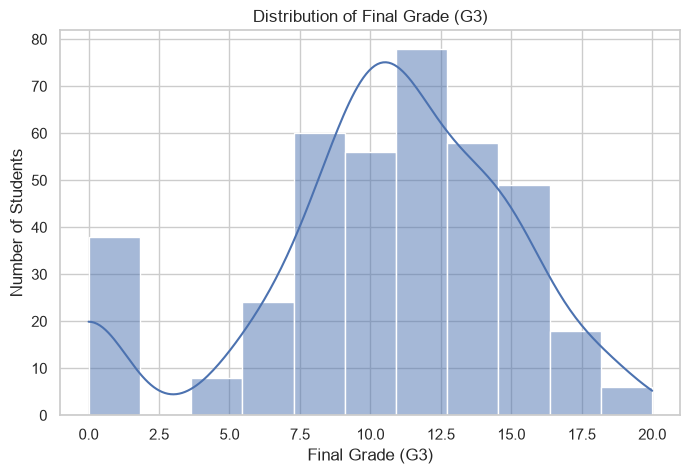

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=11, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()


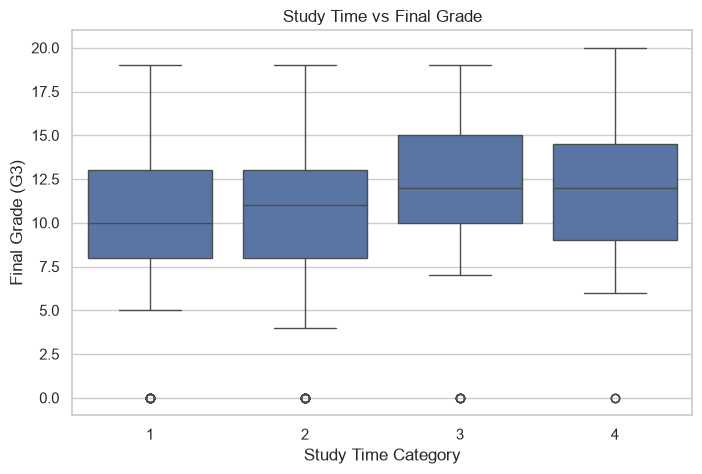

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="studytime", y="G3")
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade (G3)")
plt.show()


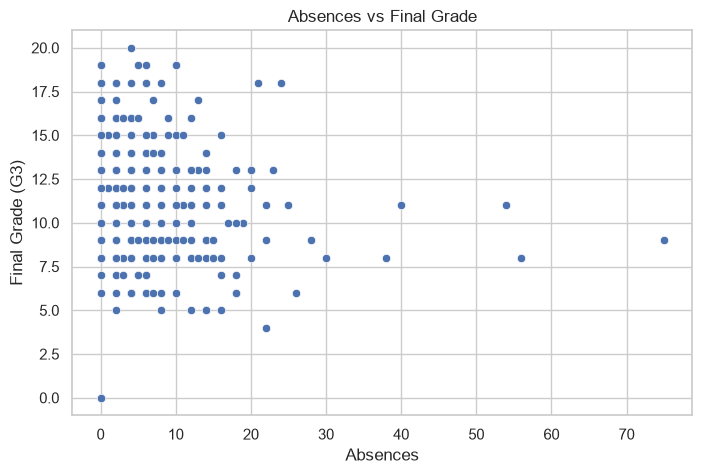

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="absences", y="G3")
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")
plt.show()


## 5. Feature Selection

`G3` is the prediction target.

`G1` and `G2` are excluded because they are earlier-period grades. Removing them makes the model rely on the other 30 available student attributes rather than directly using previous grades to predict the final grade.


In [10]:
y = df["G3"]
X = df.drop(columns=["G3", "G1", "G2"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (395, 30)
Target shape: (395,)


In [11]:
categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object", "string"]
).columns.tolist()

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)
print("\nTotal input features:", len(X.columns))


Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Total input features: 30


## 6. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 316
Testing samples: 79


## 7. Data Preprocessing

Categorical variables are converted into numerical columns using **One-Hot Encoding**.

Numerical variables are passed through unchanged.

`ColumnTransformer` applies the appropriate preprocessing to each feature type.


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)


## 8. Compare Multiple Regression Models

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

model_results = pd.DataFrame(results).sort_values("MAE")
model_results


,Model,MAE,RMSE,R2
1,Random Forest,2.997595,3.794886,0.297677
2,Gradient Boosting,3.113394,3.925861,0.248361
4,KNN,3.334177,4.226079,0.129007
0,Linear Regression,3.395261,4.195681,0.141492
5,SVR,3.468698,4.320126,0.089810
3,Decision Tree,3.594937,4.783939,-0.116119


### Initial Model Comparison

The initial comparison showed Random Forest performing best among the tested models on the held-out test set.

The project also uses cross-validation to obtain a more robust estimate of model performance.


In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=kf,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV R2": scores["test_r2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV MAE")
cv_results_df


,Model,CV MAE,CV RMSE,CV R2
1,Random Forest,2.855595,3.795564,0.300592
2,Gradient Boosting,3.038143,3.893806,0.261692
4,KNN,3.132658,4.175166,0.156342
5,SVR,3.297523,4.425096,0.055395
0,Linear Regression,3.418546,4.453874,0.025599
3,Decision Tree,3.967089,5.446741,-0.463223


## 9. Random Forest Hyperparameter Tuning

Hyperparameter tuning is performed **only on the training data**. The test set remains untouched until the final evaluation.

The search considers:
- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required to split a node (`min_samples_split`)
- Minimum samples required at a leaf (`min_samples_leaf`)


In [16]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest cross-validation MAE:", -grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


KeyboardInterrupt: 

### Expected tuned configuration from the completed project

The completed project selected:

- `n_estimators = 300`
- `max_depth = 15`
- `min_samples_split = 5`
- `min_samples_leaf = 1`

The tuning was performed on `X_train` and `y_train` only.


In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5
test_r2 = r2_score(y_test, y_pred)

print("Final Test Set Evaluation")
print("-------------------------")
print(f"MAE : {test_mae:.3f}")
print(f"RMSE: {test_rmse:.3f}")
print(f"R²  : {test_r2:.3f}")


## 10. Error Analysis

Error is calculated as:

`Actual - Predicted`

A negative mean error indicates that, on average, predictions were slightly higher than the actual values.


In [ ]:
errors = y_test - y_pred

print("Mean error:", errors.mean())
print("Largest overprediction:", errors.min())
print("Largest underprediction:", errors.max())


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

plt.figure(figsize=(7, 6))
sns.scatterplot(data=comparison, x="Actual", y="Predicted")
plt.plot([0, 20], [0, 20], linestyle="--")
plt.title("Actual vs Predicted Final Grade")
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.show()


## 11. Train the Final Model on the Complete Dataset

After evaluating the tuned model on the untouched test set, the final pipeline is trained on all available records so it can be used by the Flask application.

The final configuration used in the completed project is:

- `n_estimators=300`
- `max_depth=15`
- `min_samples_split=5`
- `min_samples_leaf=1`


In [ ]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=42
    ))
])

final_model.fit(X, y)

joblib.dump(final_model, "../model/student_performance_model.pkl")

print("Final model saved successfully!")
print("Location: ../model/student_performance_model.pkl")


## 12. Final Project Results

The completed project used the tuned Random Forest pipeline.

**Held-out test-set performance:**

| Metric | Result |
|---|---:|
| MAE | 2.992 |
| RMSE | 3.756 |
| R² | 0.312 |

### Interpretation

- **MAE = 2.992:** predictions differed from actual grades by about 3 grade points on average.
- **RMSE = 3.756:** larger prediction errors have a stronger effect on this metric.
- **R² = 0.312:** the model explains about 31.2% of the variance in final grades on the held-out test data.

This is a regression problem, so these values should not be described as classification accuracy.


## 13. Flask Application Flow

The trained pipeline is integrated into a Flask web application.

```text
User enters student information
            ↓
       HTML + CSS form
            ↓
       Flask POST request
            ↓
     Pandas DataFrame
            ↓
Saved preprocessing + Random Forest pipeline
            ↓
      Predicted final grade
            ↓
      Result displayed in browser
```

The web application files are:

- `app.py` — Flask backend
- `templates/index.html` — frontend structure
- `static/style.css` — frontend styling
- `model/student_performance_model.pkl` — trained ML pipeline


## 14. Key Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Flask
- HTML
- CSS
- Git
- GitHub
